In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
data = pd.read_csv("/content/drive/MyDrive/train.csv")


In [8]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
data = np.array(data)
m,n = data.shape
np.random.shuffle(data)


In [14]:
print(m,n)

42000 785


In [45]:
train_data = data[0:int(0.8*m),:]
val_data = data[int(0.8*m):m,:]
X_train = train_data[:,1:].transpose()
X_train = X_train / 255
Y_train = train_data[:,0]

X_val = val_data[:,1:].transpose()
X_val = X_val / 255
Y_val = val_data[:,0]


In [46]:
print(X_train.shape,Y_train.shape)
print(X_val.shape,Y_val.shape)

(784, 33600) (33600,)
(784, 8400) (8400,)


In [47]:
def initialize_parameters():
  W1 = np.random.rand(10,784)-0.5
  B1 = np.random.rand(10,1)-0.5
  W2 = np.random.rand(10,10)-0.5
  B2 = np.random.rand(10,1)-0.5
  return W1,B1,W2,B2

def ReLU(X):
  return np.maximum(X,0)
def softmax_calculator(Z):
  # Add a small epsilon to prevent division by zero if sum(np.exp(Z)) is zero
  exp_Z = np.exp(Z)
  return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def forward_propogation(W1,B1,W2,B2,X):
  Z1 = W1.dot(X) + B1
  A1 = ReLU(Z1)
  Z2 = W2.dot(A1) + B2
  A2 = softmax_calculator(Z2)
  return Z1,A1,Z2,A2

def one_hot_converter(Y):
  one_hot_Y = np.zeros((Y.size,Y.max()+1))
  one_hot_Y[np.arange(Y.size),Y] = 1
  one_hot_Y = one_hot_Y.T
  return one_hot_Y
def backward_propagation(W1,B1,W2,B2,Z1,A1,Z2,A2,X,Y):
   current_m = X.shape[1] # Number of samples in the current batch
   one_hot_Y= one_hot_converter(Y)
   dZ2 = A2 - one_hot_Y
   dW2 = 1/current_m * dZ2.dot(A1.T)
   dB2 = 1/current_m * np.sum(dZ2, axis=1, keepdims=True)
   dZ1 = W2.T.dot(dZ2) * (Z1 > 0)
   dW1 = 1/current_m * dZ1.dot(X.T)
   dB1 = 1/current_m * np.sum(dZ1, axis=1, keepdims=True)
   return dW1,dB1,dW2,dB2


def update_parameters(W1,B1,W2,B2,dW1,dB1,dW2,dB2,learning_rate):
  W1 = W1-learning_rate*dW1
  B1 = B1 - learning_rate*dB1
  W2 = W2-learning_rate*dW2
  B2 = B2-learning_rate*dB2
  return W1,B1,W2,B2

def get_predictions(A2):
  return np.argmax(A2,0)
def get_accuracy(predictions,Y):
  return np.sum(predictions==Y)/Y.size

def gradient_descent(X,Y,alpha,iterations):
  W1,B1,W2,B2 = initialize_parameters()
  for i in range(iterations):
    Z1,A1,Z2,A2 = forward_propogation(W1,B1,W2,B2,X)
    dW1,dB1,dW2,dB2 = backward_propagation(W1,B1,W2,B2,Z1,A1,Z2,A2,X,Y)
    W1,B1,W2,B2 = update_parameters(W1,B1,W2,B2,dW1,dB1,dW2,dB2,alpha)
    if (i%20) == 0:
      print("Iteration: ",i)
      print("Accuracy: ",get_accuracy(get_predictions(A2),Y))
  return W1,B1,W2,B2

In [52]:
W1,B1,W2,B2 = gradient_descent(X_train,Y_train,0.1 ,1000
                               )

Iteration:  0
Accuracy:  0.08568452380952381
Iteration:  20
Accuracy:  0.24267857142857144
Iteration:  40
Accuracy:  0.3541964285714286
Iteration:  60
Accuracy:  0.4394345238095238
Iteration:  80
Accuracy:  0.500625
Iteration:  100
Accuracy:  0.5470833333333334
Iteration:  120
Accuracy:  0.5915476190476191
Iteration:  140
Accuracy:  0.627470238095238
Iteration:  160
Accuracy:  0.6604464285714285
Iteration:  180
Accuracy:  0.6880952380952381
Iteration:  200
Accuracy:  0.7116071428571429
Iteration:  220
Accuracy:  0.7297916666666666
Iteration:  240
Accuracy:  0.7455357142857143
Iteration:  260
Accuracy:  0.7582440476190476
Iteration:  280
Accuracy:  0.7700892857142857
Iteration:  300
Accuracy:  0.7799404761904762
Iteration:  320
Accuracy:  0.7883035714285714
Iteration:  340
Accuracy:  0.795952380952381
Iteration:  360
Accuracy:  0.803125
Iteration:  380
Accuracy:  0.8093154761904762
Iteration:  400
Accuracy:  0.8148809523809524
Iteration:  420
Accuracy:  0.8191369047619048
Iteration:  44

Predicted label [3]
Actual label 3


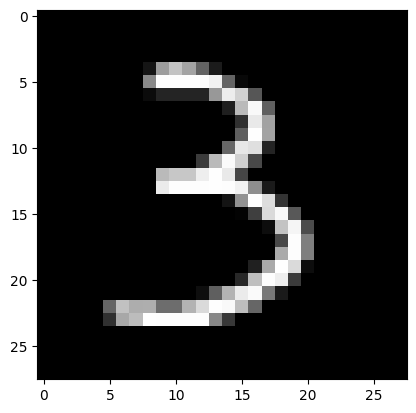

In [57]:
val_index=7
Z1val,A1val,Z2val,A2val = forward_propogation(W1,B1,W2,B2,X_val[:,val_index,None])
print("Predicted label",get_predictions(A2val))
print("Actual label",Y_val[val_index])
image_array = X_val[:,val_index].reshape(28,28)
plt.imshow(image_array, cmap='gray')
plt.show()


In [59]:
Z1val,A1val,Z2val,A2val = forward_propogation(W1,B1,W2,B2,X_val)
get_accuracy(get_predictions(A2val),Y_val)

print("validation accuracy:" ,get_accuracy(get_predictions(A2val),Y_val))

validation accuracy: 0.8791666666666667
